XGBoost 完整调参（粗调 + 精调）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import time
import json
import os
import warnings
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("数据准备完成")
print(f"特征数: {X.shape[1]}")
print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 加载之前的模型做对比
baseline_results = {}

# Day 15 默认
try:
    m = joblib.load('../models/day15_xgboost_default.pkl')
    baseline_results['Day15 默认'] = m.score(X_test, y_test)
except:
    baseline_results['Day15 默认'] = None

# Day 16 树参数
try:
    m = joblib.load('../models/day16_xgb_tuned_trees.pkl')
    baseline_results['Day16 树参数'] = m.score(X_test, y_test)
except:
    baseline_results['Day16 树参数'] = None

# Day 17 学习参数
try:
    m = joblib.load('../models/day17_xgb_tuned_learning.pkl')
    baseline_results['Day17 学习参数'] = m.score(X_test, y_test)
except:
    baseline_results['Day17 学习参数'] = None

print("\n之前模型的测试集 R²:")
for name, r2 in baseline_results.items():
    if r2 is not None:
        print(f"  {name}: {r2:.4f}")
    else:
        print(f"  {name}: 未找到")

数据准备完成
特征数: 135
训练集: 3811 样本
测试集: 953 样本

之前模型的测试集 R²:
  Day15 默认: 0.6178
  Day16 树参数: 0.6555
  Day17 学习参数: 0.6828


第一步：随机搜索（粗调）
在 6 个参数的广阔空间里随机采样 50 组，快速找到大致方向

In [2]:
print("=" * 70)
print("第一步：RandomizedSearchCV 随机搜索（粗调）")
print("=" * 70)

# 参数空间——范围比较大，让随机搜索去探路
param_distributions = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

n_combinations = np.prod([len(v) for v in param_distributions.values()])
n_iter = 50
print(f"\n参数空间总组合数: {n_combinations}")
print(f"随机搜索: {n_iter} 组 × 3 折 CV = {n_iter * 3} 次训练")
print(f"覆盖率: {n_iter / n_combinations * 100:.1f}%")

# 随机搜索
# XGBoost n_jobs=1 让 RandomizedSearchCV 并行
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(
        tree_method='hist',  # 不加这个会非常慢
        random_state=42,
        n_jobs=1
    ),
    param_distributions=param_distributions,
    n_iter=n_iter,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\n开始随机搜索...")
start = time.time()
random_search.fit(X_train, y_train)
coarse_time = time.time() - start

print(f"\n✓ 随机搜索完成，耗时 {coarse_time:.1f}s")
print(f"  最佳参数: {random_search.best_params_}")
print(f"  最佳 CV R²: {random_search.best_score_:.4f}")
print(f"  测试集 R²: {random_search.score(X_test, y_test):.4f}")

第一步：RandomizedSearchCV 随机搜索（粗调）

参数空间总组合数: 1296
随机搜索: 50 组 × 3 折 CV = 150 次训练
覆盖率: 3.9%

开始随机搜索...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

✓ 随机搜索完成，耗时 103.8s
  最佳参数: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
  最佳 CV R²: 0.5804
  测试集 R²: 0.6928


第二步：网格搜索（精调）
在粗调最佳值附近缩小范围，用 5 折 CV 精细搜索

In [3]:
print("=" * 70)
print("第二步：GridSearchCV 网格搜索（精调）")
print("=" * 70)

best_coarse = random_search.best_params_

# 在粗调最佳值周围 ±1 范围内精调
param_grid_fine = {
    'max_depth': [
        max(3, best_coarse['max_depth'] - 1),
        best_coarse['max_depth'],
        best_coarse['max_depth'] + 1
    ],
    'learning_rate': [
        max(0.01, best_coarse['learning_rate'] * 0.7),
        best_coarse['learning_rate'],
        min(0.5, best_coarse['learning_rate'] * 1.3)
    ],
    'subsample': [
        max(0.5, best_coarse['subsample'] - 0.1),
        best_coarse['subsample'],
        min(1.0, best_coarse['subsample'] + 0.1)
    ],
    'colsample_bytree': [
        max(0.5, best_coarse['colsample_bytree'] - 0.1),
        best_coarse['colsample_bytree'],
        min(1.0, best_coarse['colsample_bytree'] + 0.1)
    ]
}

n_fine = np.prod([len(v) for v in param_grid_fine.values()])
print(f"\n精调参数组合数: {n_fine} × 5 折 CV = {n_fine * 5} 次训练")
print(f"精调范围: {param_grid_fine}")

grid_search_fine = GridSearchCV(
    estimator=xgb.XGBRegressor(
        n_estimators=best_coarse['n_estimators'],
        min_child_weight=best_coarse.get('min_child_weight', 1),
        tree_method='hist',
        random_state=42,
        n_jobs=1
    ),
    param_grid=param_grid_fine,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("\n开始精调...")
start = time.time()
grid_search_fine.fit(X_train, y_train)
fine_time = time.time() - start

print(f"\n✓ 精调完成，耗时 {fine_time:.1f}s")
print(f"  最佳参数: {grid_search_fine.best_params_}")
print(f"  最佳 CV R²: {grid_search_fine.best_score_:.4f}")
print(f"  测试集 R²: {grid_search_fine.score(X_test, y_test):.4f}")

第二步：GridSearchCV 网格搜索（精调）

精调参数组合数: 81 × 5 折 CV = 405 次训练
精调范围: {'max_depth': [6, 7, 8], 'learning_rate': [0.01, 0.01, 0.013000000000000001], 'subsample': [0.5, 0.6, 0.7], 'colsample_bytree': [0.5, 0.6, 0.7]}

开始精调...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✓ 精调完成，耗时 364.9s
  最佳参数: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 8, 'subsample': 0.5}
  最佳 CV R²: 0.5861
  测试集 R²: 0.6936


第三步：最终验证
用精调最佳参数训练最终模型，对比所有阶段

In [4]:
# 最终模型：精调参数 + 更多树
final_params = grid_search_fine.best_params_.copy()
final_params.update({
    'n_estimators': best_coarse['n_estimators'],  # 用粗调确定的树数量
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1
})

print("最终模型参数:")
for k, v in final_params.items():
    print(f"  {k}: {v}")

final_model = xgb.XGBRegressor(**final_params)
final_model.fit(X_train, y_train)

train_r2 = final_model.score(X_train, y_train)
test_r2 = final_model.score(X_test, y_test)

print(f"\n最终模型性能:")
print(f"  训练集 R²: {train_r2:.4f}")
print(f"  测试集 R²: {test_r2:.4f}")
print(f"  过拟合 Gap: {train_r2 - test_r2:.4f}")

# 3 折 CV 确认
cv_scores = cross_val_score(final_model, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
print(f"  3 折 CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

最终模型参数:
  colsample_bytree: 0.5
  learning_rate: 0.01
  max_depth: 8
  subsample: 0.5
  n_estimators: 500
  tree_method: hist
  random_state: 42
  n_jobs: -1

最终模型性能:
  训练集 R²: 0.9207
  测试集 R²: 0.6896
  过拟合 Gap: 0.2311
  3 折 CV: 0.5708 ± 0.0524



全阶段模型对比
  Day15 默认             R²=0.6178
  Day16 树参数            R²=0.6555
  Day17 学习参数           R²=0.6828
  Day18-19 最终          R²=0.6896

相比 Day17 提升: +0.0068


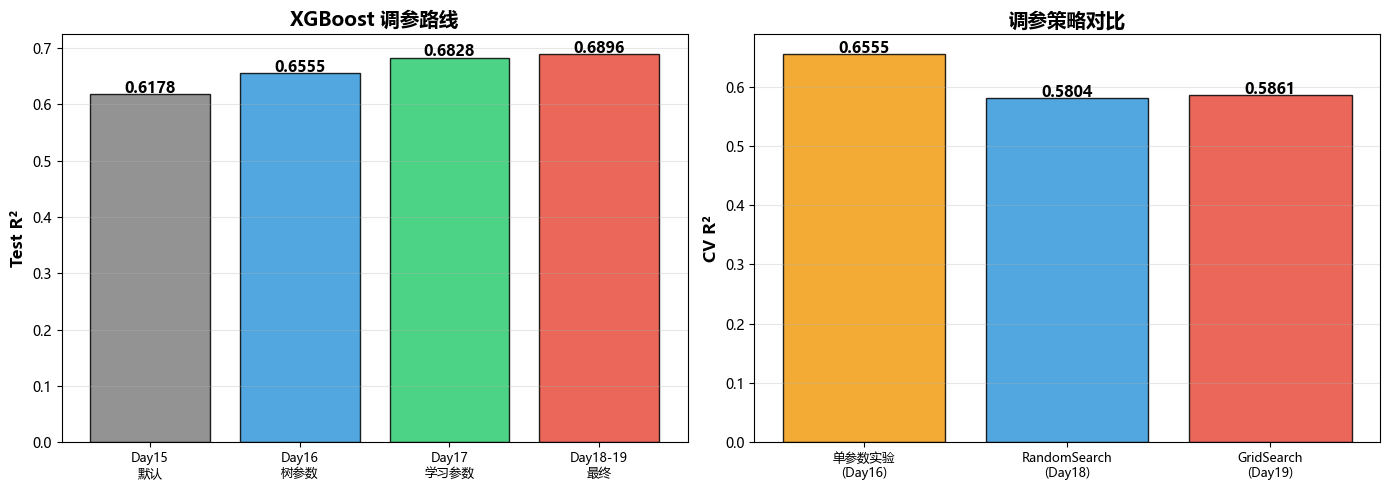


✓ 对比图已保存


In [5]:
# 对比所有阶段
print("\n" + "=" * 70)
print("全阶段模型对比")
print("=" * 70)

all_results = dict(baseline_results)
all_results['Day18-19 最终'] = test_r2

for name, r2 in all_results.items():
    if r2 is not None:
        print(f"  {name:20s} R²={r2:.4f}")

if baseline_results.get('Day17 学习参数'):
    improvement = test_r2 - baseline_results['Day17 学习参数']
    print(f"\n相比 Day17 提升: {improvement:+.4f}")

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：各阶段 R²
stages = [k for k in all_results if all_results[k] is not None]
r2s = [all_results[k] for k in stages]
colors = ['gray', '#3498db', '#2ecc71', '#e74c3c'][:len(stages)]

ax1 = axes[0]
bars = ax1.bar(range(len(stages)), r2s, color=colors, alpha=0.85, edgecolor='black')
ax1.set_xticks(range(len(stages)))
ax1.set_xticklabels([s.replace(' ', '\n') for s in stages], fontsize=9)
ax1.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax1.set_title('XGBoost 调参路线', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# 右：调参策略对比
ax2 = axes[1]
methods = ['单参数实验\n(Day16)', 'RandomSearch\n(Day18)', 'GridSearch\n(Day19)']
method_r2 = [
    all_results.get('Day16 树参数', None),
    random_search.best_score_,
    grid_search_fine.best_score_
]
method_r2_clean = [r for r, m in zip(method_r2, methods) if r is not None]
methods_clean = [m for r, m in zip(method_r2, methods) if r is not None]

colors2 = ['#f39c12', '#3498db', '#e74c3c'][:len(methods_clean)]
bars2 = ax2.bar(range(len(methods_clean)), method_r2_clean, color=colors2, alpha=0.85, edgecolor='black')
ax2.set_xticks(range(len(methods_clean)))
ax2.set_xticklabels(methods_clean, fontsize=9)
ax2.set_ylabel('CV R²', fontsize=12, fontweight='bold')
ax2.set_title('调参策略对比', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, method_r2_clean):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/day18_full_tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ 对比图已保存")

In [6]:
# 保存模型
joblib.dump(final_model, '../models/day18_xgb_final.pkl')
print("✓ 最终模型已保存到 ../models/day18_xgb_final.pkl")

# 保存调参结果
def to_python(obj):
    """numpy 类型转 Python 原生类型"""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_python(v) for v in obj]
    return obj

tuning_summary = {
    'method': 'RandomSearch(coarse) + GridSearch(fine)',
    'coarse_search': {
        'method': 'RandomizedSearchCV',
        'n_iter': n_iter,
        'best_params': to_python(random_search.best_params_),
        'best_cv_r2': float(random_search.best_score_),
        'time_seconds': float(coarse_time)
    },
    'fine_search': {
        'method': 'GridSearchCV',
        'n_combinations': int(n_fine),
        'best_params': to_python(grid_search_fine.best_params_),
        'best_cv_r2': float(grid_search_fine.best_score_),
        'time_seconds': float(fine_time)
    },
    'final_model': {
        'params': to_python(final_params),
        'train_r2': float(train_r2),
        'test_r2': float(test_r2),
        'cv_r2_mean': float(cv_scores.mean()),
        'cv_r2_std': float(cv_scores.std()),
        'overfitting_gap': float(train_r2 - test_r2)
    },
    'comparison_with_previous': to_python(all_results)
}

with open('../models/day18_full_tuning.json', 'w') as f:
    json.dump(tuning_summary, f, indent=2)

print("✓ 调参结果已保存到 ../models/day18_full_tuning.json")

# 最终总结
print("\n" + "=" * 70)
print("Day 18-19 总结")
print("=" * 70)

print(f"\n调参路线:")
print(f"  随机搜索 ({n_iter} 组 × 3CV) → 网格搜索 ({n_fine} 组 × 5CV) → 最终验证")
print(f"  总耗时: {coarse_time + fine_time:.1f}s")

print(f"\n最终参数:")
for k, v in grid_search_fine.best_params_.items():
    print(f"  {k}: {v}")

print(f"\n最终性能: R²={test_r2:.4f}, CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}")
print(f"过拟合 Gap: {train_r2 - test_r2:.4f}")

print("=" * 70)

✓ 最终模型已保存到 ../models/day18_xgb_final.pkl
✓ 调参结果已保存到 ../models/day18_full_tuning.json

Day 18-19 总结

调参路线:
  随机搜索 (50 组 × 3CV) → 网格搜索 (81 组 × 5CV) → 最终验证
  总耗时: 468.7s

最终参数:
  colsample_bytree: 0.5
  learning_rate: 0.01
  max_depth: 8
  subsample: 0.5

最终性能: R²=0.6896, CV=0.5708±0.0524
过拟合 Gap: 0.2311
